In [1]:
import pandas as pd 
import tensorflow as tf 
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, roc_auc_score
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.callbacks import EarlyStopping

In [2]:
df = pd.read_csv('Titanic.csv')
df.head()

,Unnamed: 0,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df['who'].value_counts()

who
man      537
woman    271
child     83
Name: count, dtype: int64

In [4]:
df.drop(['Unnamed: 0', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone'], axis=1, inplace=True)

In [5]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [6]:
df.shape

(891, 8)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [8]:
df.isnull().sum()

survived      0
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
dtype: int64

In [9]:
median_age = df['age'].median()
print(f'Median age: {median_age}')

Median age: 28.0


In [10]:
df['age'].fillna(median_age, inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_42840\19657950.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(median_age, inplace=True)


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       891 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [12]:
mode_embarked = df['embarked'].mode()[0]
print(f'Mode of embarked: {mode_embarked}')

Mode of embarked: S


In [13]:
df['embarked'].fillna(mode_embarked, inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_42840\568535148.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['embarked'].fillna(mode_embarked, inplace=True)


In [14]:
df.isnull().sum()

survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64

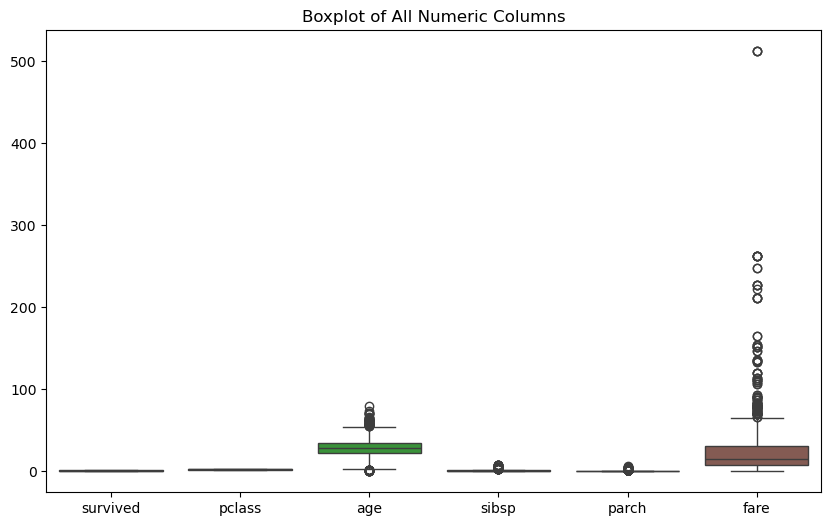

In [15]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df)
plt.title('Boxplot of All Numeric Columns')
plt.show()

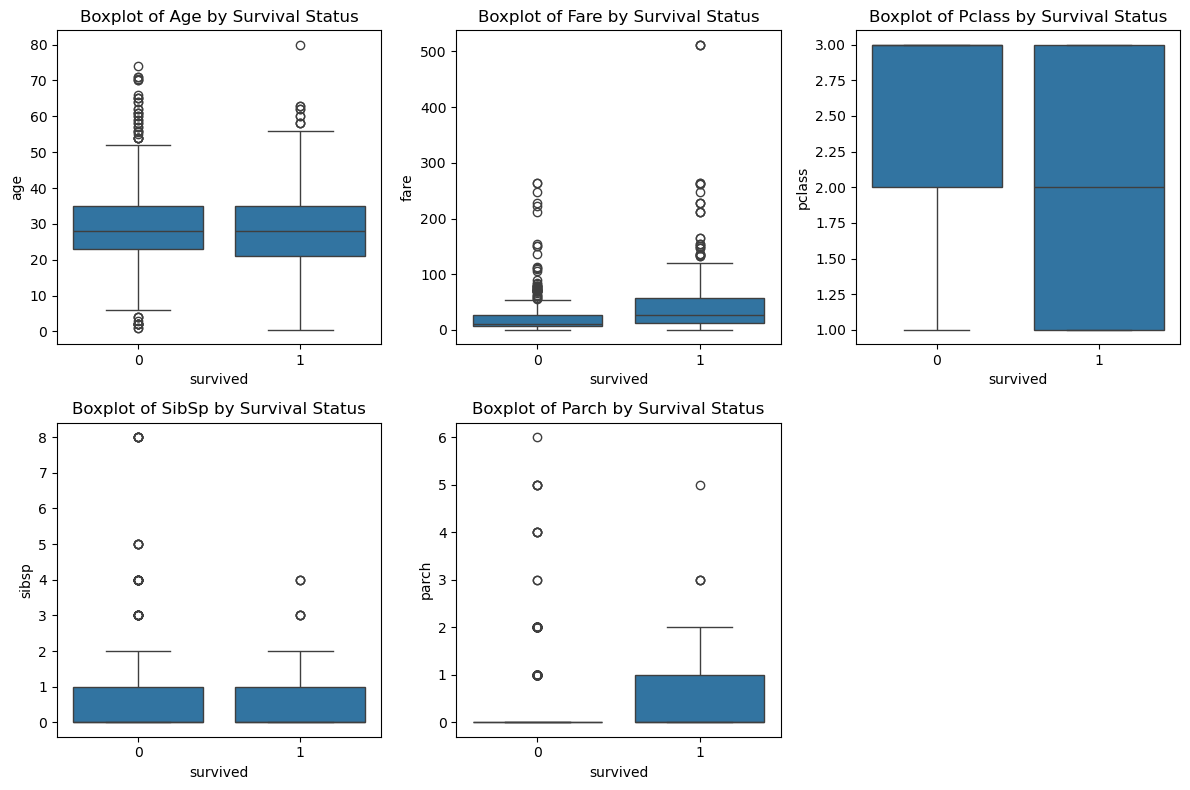

In [16]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
sns.boxplot(x='survived', y='age', data=df)
plt.title('Boxplot of Age by Survival Status')

plt.subplot(2, 3, 2)
sns.boxplot(x='survived', y='fare', data=df)
plt.title('Boxplot of Fare by Survival Status')

plt.subplot(2, 3, 3)
sns.boxplot(x='survived', y='pclass', data=df)
plt.title('Boxplot of Pclass by Survival Status')

plt.subplot(2, 3, 4)
sns.boxplot(x='survived', y='sibsp', data=df)
plt.title('Boxplot of SibSp by Survival Status')

plt.subplot(2, 3, 5)
sns.boxplot(x='survived', y='parch', data=df)
plt.title('Boxplot of Parch by Survival Status')

plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

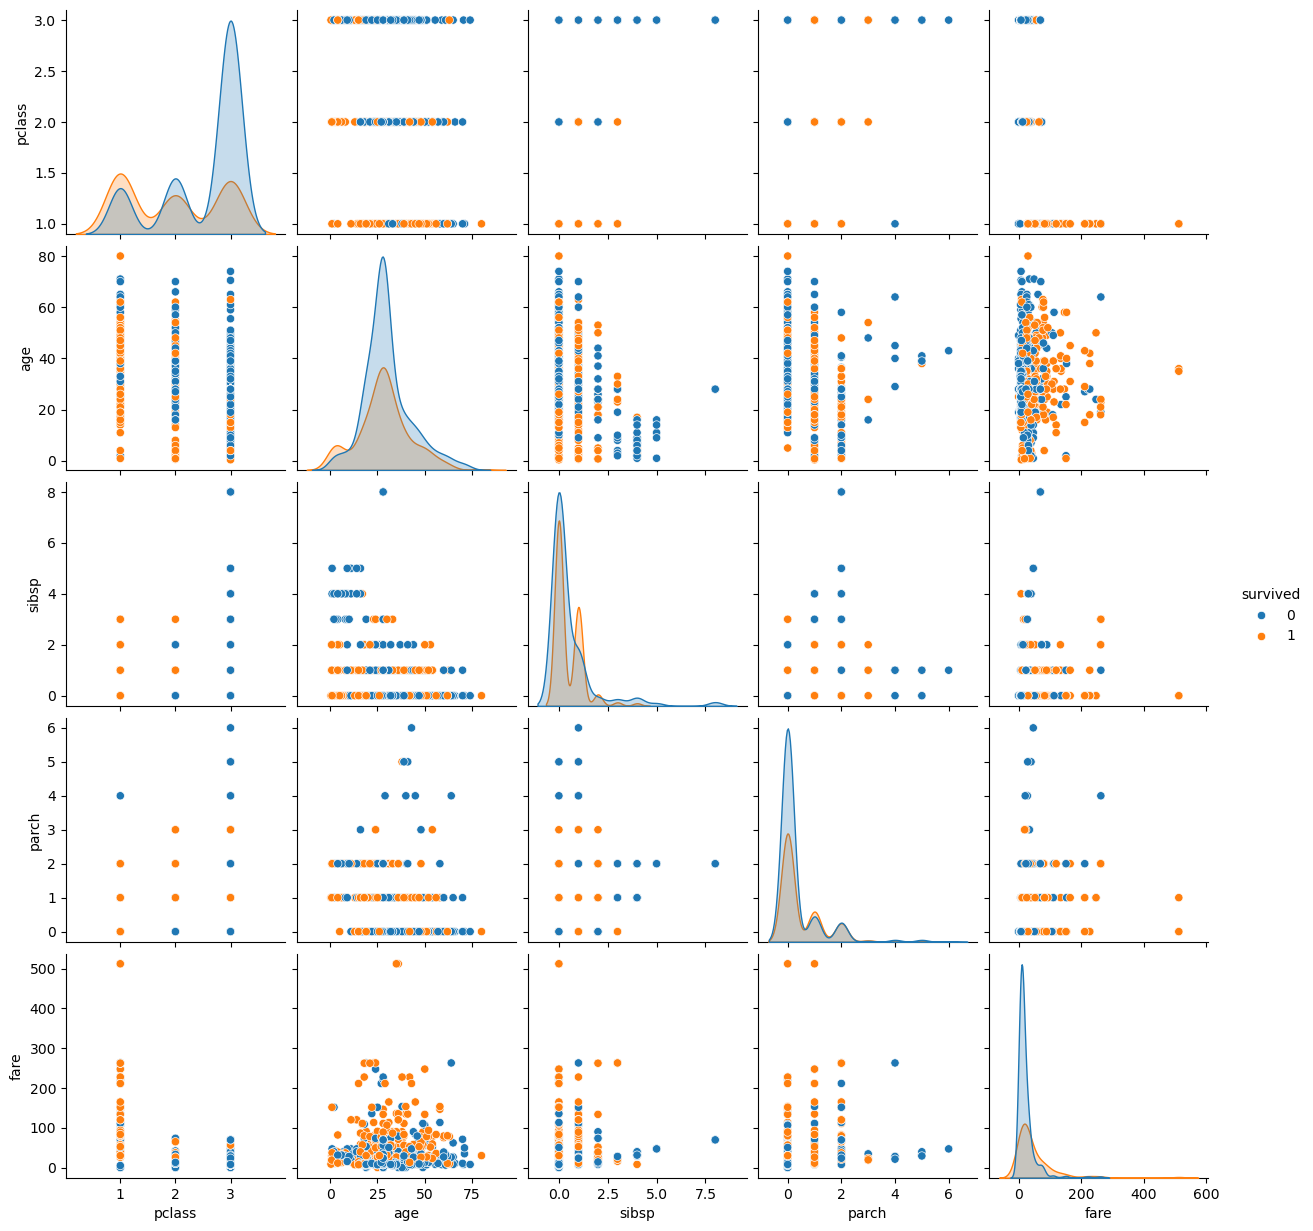

In [17]:
plt.figure(figsize=(10, 6))
sns.pairplot(df, hue='survived')
plt.show()

In [18]:
categorical_cols = df.select_dtypes(include=['object']).columns
print(f'Categorical columns: {categorical_cols}')

Categorical columns: Index(['sex', 'embarked'], dtype='object')


In [19]:
le = LabelEncoder()
df[categorical_cols] = df[categorical_cols].apply(lambda x: le.fit_transform(x.astype(str)))

In [20]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


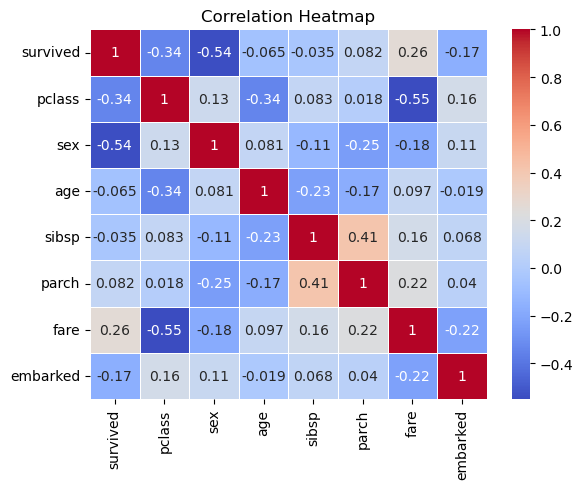

In [21]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

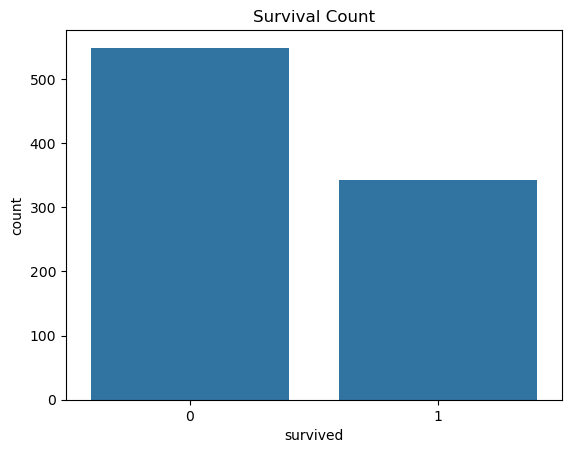

In [22]:
sns.countplot(data=df, x='survived')
plt.title('Survival Count')
plt.show()

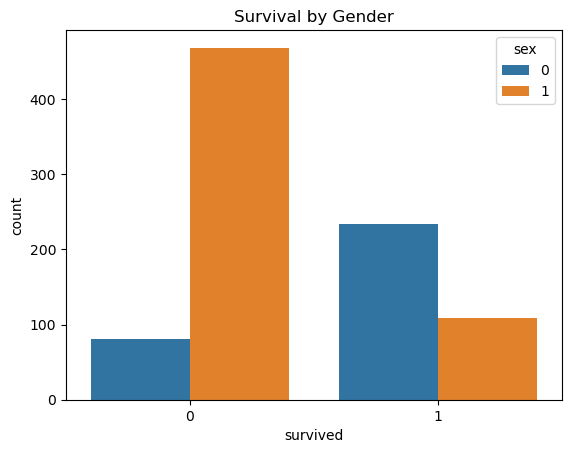

In [23]:
sns.countplot(data=df, x='survived', hue='sex')
plt.title('Survival by Gender')
plt.show()

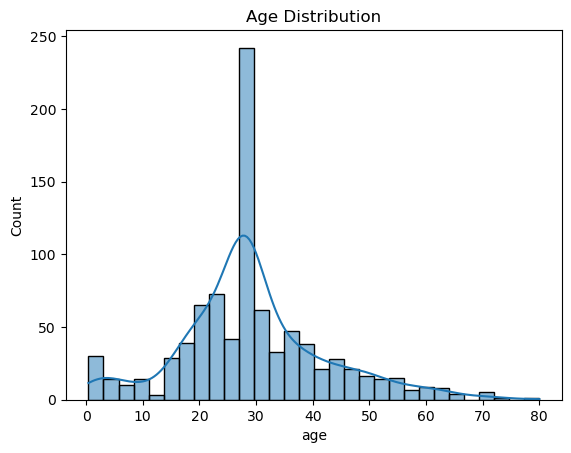

In [24]:
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_42840\4209935190.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df[df['survived']==0]['age'], label='Not Survived', shade=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_42840\4209935190.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df[df['survived']==1]['age'], label='Survived', shade=True)


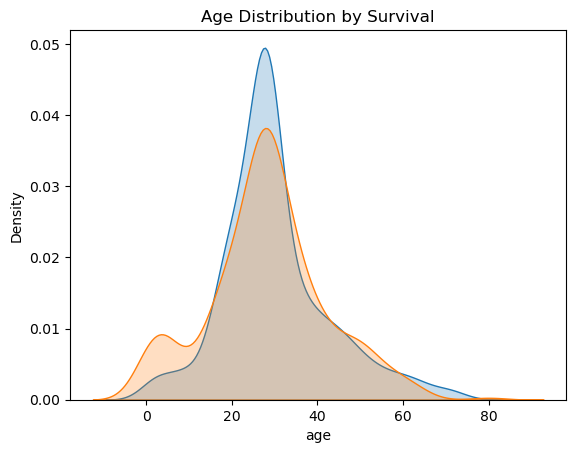

In [25]:
sns.kdeplot(data=df[df['survived']==0]['age'], label='Not Survived', shade=True)
sns.kdeplot(data=df[df['survived']==1]['age'], label='Survived', shade=True)
plt.title('Age Distribution by Survival')
plt.show()

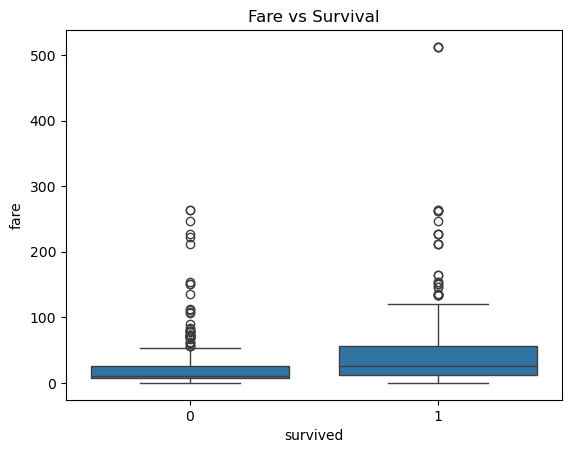

In [26]:
sns.boxplot(x='survived', y='fare', data=df)
plt.title('Fare vs Survival')
plt.show()


In [27]:
df['FamilySize'] = df['sibsp'] + df['parch'] + 1

In [28]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,FamilySize
0,0,3,1,22.0,1,0,7.2500,2,2
1,1,1,0,38.0,1,0,71.2833,0,2
2,1,3,0,26.0,0,0,7.9250,2,1
3,1,1,0,35.0,1,0,53.1000,2,2
4,0,3,1,35.0,0,0,8.0500,2,1


In [29]:
df['AgeGroup'] = pd.cut(
    df['age'],
    bins=[0,12,20,40,60,80],
    labels=['Child','Teen','Adult','MidAge','Senior']
)
df.sample(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,FamilySize,AgeGroup
120,0,2,1,21.00,2,0,73.5000,2,3,Adult
644,1,3,0,0.75,2,1,19.2583,0,4,Child
268,1,1,0,58.00,0,1,153.4625,2,2,MidAge
655,0,2,1,24.00,2,0,73.5000,2,3,Adult
402,0,3,0,21.00,1,0,9.8250,2,2,Adult
283,1,3,1,19.00,0,0,8.0500,2,1,Teen
764,0,3,1,16.00,0,0,7.7750,2,1,Teen
712,1,1,1,48.00,1,0,52.0000,2,2,MidAge
70,0,2,1,32.00,0,0,10.5000,2,1,Adult
807,0,3,0,18.00,0,0,7.7750,2,1,Teen


In [32]:
df = pd.get_dummies(df, columns=['AgeGroup'], drop_first=True)

In [33]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,FamilySize,AgeGroup_Teen,AgeGroup_Adult,AgeGroup_MidAge,AgeGroup_Senior
0,0,3,1,22.0,1,0,7.2500,2,2,False,True,False,False
1,1,1,0,38.0,1,0,71.2833,0,2,False,True,False,False
2,1,3,0,26.0,0,0,7.9250,2,1,False,True,False,False
3,1,1,0,35.0,1,0,53.1000,2,2,False,True,False,False
4,0,3,1,35.0,0,0,8.0500,2,1,False,True,False,False


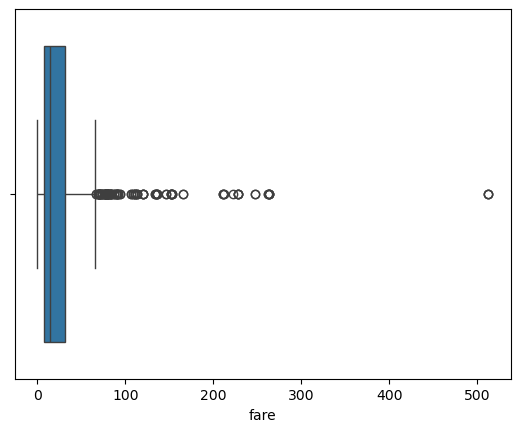

In [34]:
sns.boxplot(x=df['fare'])
plt.show()

In [35]:
df['fare'] = np.log1p(df['fare'])
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,FamilySize,AgeGroup_Teen,AgeGroup_Adult,AgeGroup_MidAge,AgeGroup_Senior
0,0,3,1,22.0,1,0,2.110213,2,2,False,True,False,False
1,1,1,0,38.0,1,0,4.280593,0,2,False,True,False,False
2,1,3,0,26.0,0,0,2.188856,2,1,False,True,False,False
3,1,1,0,35.0,1,0,3.990834,2,2,False,True,False,False
4,0,3,1,35.0,0,0,2.202765,2,1,False,True,False,False


In [36]:
scaler = StandardScaler()

scale_cols = ['age','fare','FamilySize','sibsp','parch']
df[scale_cols] = scaler.fit_transform(df[scale_cols])

In [37]:
X = df.drop('survived', axis=1)
y = df['survived']

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f'Training set shape: {X_train.shape}')
print(f'Test set shape: {X_test.shape}')
print(f'Training set shape: {y_train.shape}')
print(f'Test set shape: {y_test.shape}')

Training set shape: (712, 12)
Test set shape: (179, 12)
Training set shape: (712,)
Test set shape: (179,)


In [39]:
df['survived'].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

In [40]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
model.summary()

c:\Users\HP\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [42]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.6442 - loss: 0.6523 - val_accuracy: 0.6783 - val_loss: 0.5906
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6707 - loss: 0.6088 - val_accuracy: 0.6993 - val_loss: 0.5672
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7049 - loss: 0.5995 - val_accuracy: 0.7133 - val_loss: 0.5522
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6632 - loss: 0.5969 - val_accuracy: 0.7203 - val_loss: 0.5368
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7256 - loss: 0.5703 - val_accuracy: 0.7273 - val_loss: 0.5249
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7321 - loss: 0.5453 - val_accuracy: 0.7413 - val_loss: 0.5122
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7329 - loss: 0.5561 - val_accuracy: 0.7413 - val_loss: 0.5005
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7553 - loss: 0.5424 - val_accuracy: 0.

In [43]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8086 - loss: 0.4236
Test Loss: 0.43259328603744507
Test Accuracy: 0.7932960987091064


In [44]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


In [45]:
cm = confusion_matrix(y_test, y_pred)

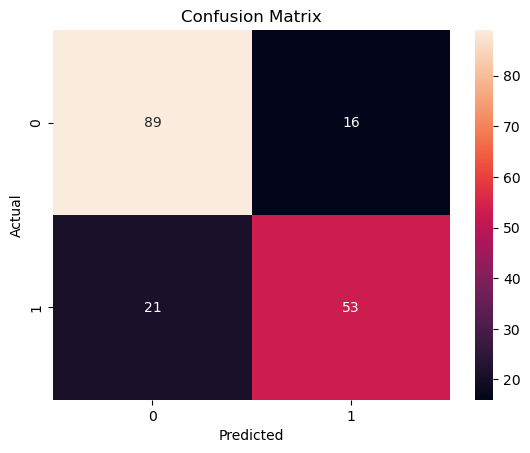

In [46]:
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [47]:
print(classification_report(y_test, y_pred))
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)

              precision    recall  f1-score   support

           0       0.81      0.85      0.83       105
           1       0.77      0.72      0.74        74

    accuracy                           0.79       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



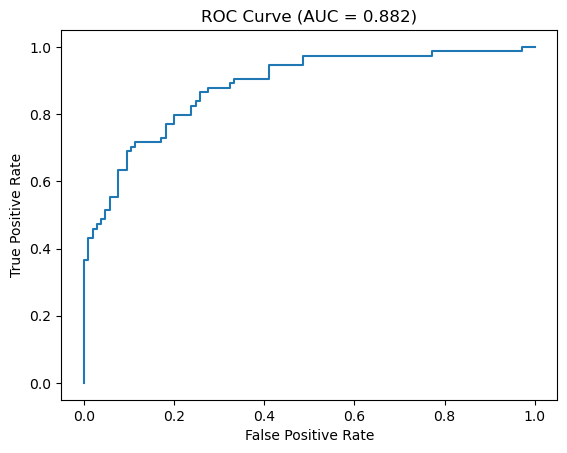

In [48]:
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (AUC = {:.3f})".format(auc_score))
plt.show()

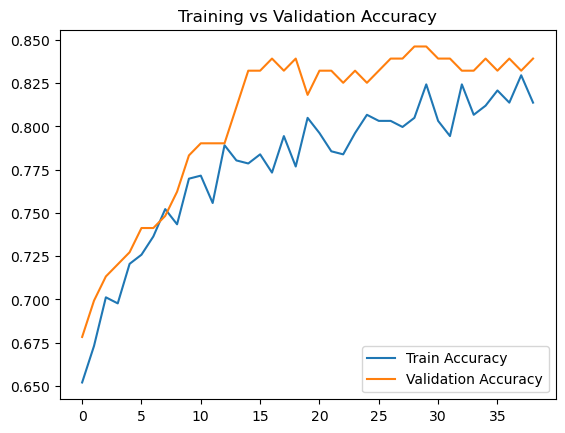

In [49]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()

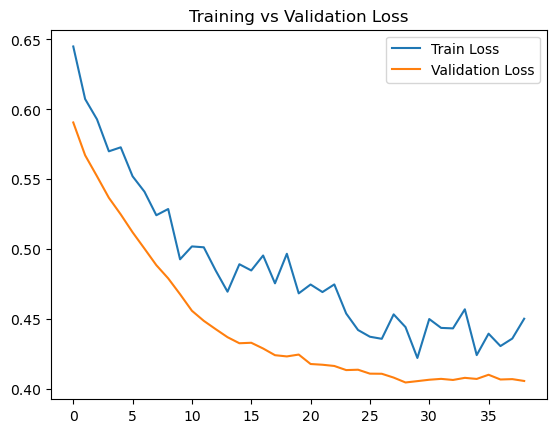

In [50]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

In [51]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [52]:
y_pred_lr = lr_model.predict(X_test)

In [53]:
print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.7932960893854749
              precision    recall  f1-score   support

           0       0.81      0.84      0.83       105
           1       0.76      0.73      0.74        74

    accuracy                           0.79       179
   macro avg       0.79      0.78      0.79       179
weighted avg       0.79      0.79      0.79       179



In [54]:
dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [55]:
y_pred_dt = dt_model.predict(X_test)

In [56]:
print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_dt))

print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7988826815642458
              precision    recall  f1-score   support

           0       0.79      0.90      0.84       105
           1       0.83      0.65      0.73        74

    accuracy                           0.80       179
   macro avg       0.81      0.78      0.78       179
weighted avg       0.80      0.80      0.79       179



In [57]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [58]:
y_pred_rf = rf_model.predict(X_test)

In [59]:
print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8268156424581006
              precision    recall  f1-score   support

           0       0.84      0.87      0.85       105
           1       0.80      0.77      0.79        74

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



In [60]:
models = {
    "Logistic Regression": lr_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model
}

# Evaluate sklearn models
for name, model in models.items():
    pred = model.predict(X_test)
    print("======", name, "======")
    print("Accuracy:", accuracy_score(y_test, pred))
    print()

# Evaluate ANN separately (because it returns probabilities)
y_pred_ann = (model.predict(X_test) > 0.5).astype(int)

print("====== ANN (Neural Network) ======")
print("Accuracy:", accuracy_score(y_test, y_pred_ann))
print()

====== Logistic Regression ======
Accuracy: 0.7932960893854749

====== Decision Tree ======
Accuracy: 0.7988826815642458

====== Random Forest ======
Accuracy: 0.8268156424581006

====== ANN (Neural Network) ======
Accuracy: 0.8268156424581006



In [61]:
ann_model = model

results = []

models = {
    "Logistic Regression": lr_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model
}

# sklearn models
for name, m in models.items():
    pred = m.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred)
    })

# ANN model
ann_pred = (ann_model.predict(X_test) > 0.5).astype(int)

results.append({
    "Model": "ANN",
    "Accuracy": accuracy_score(y_test, ann_pred),
    "Precision": precision_score(y_test, ann_pred),
    "Recall": recall_score(y_test, ann_pred),
    "F1 Score": f1_score(y_test, ann_pred)
})

results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.793296   0.760563  0.729730  0.744828
1        Decision Tree  0.798883   0.827586  0.648649  0.727273
2        Random Forest  0.826816   0.802817  0.770270  0.786207
3                  ANN  0.826816   0.802817  0.770270  0.786207


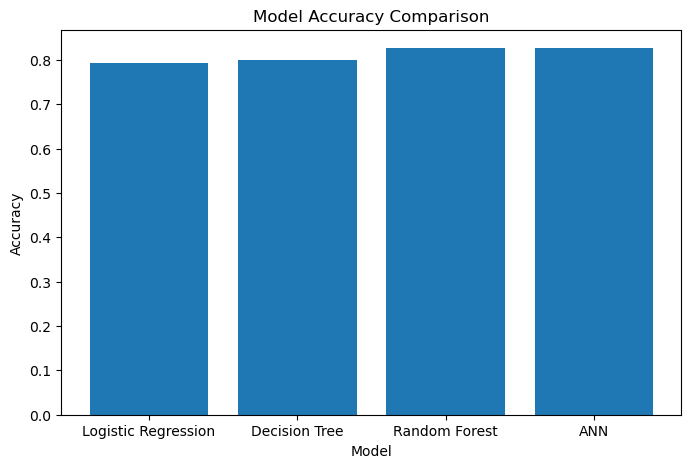

In [62]:
plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


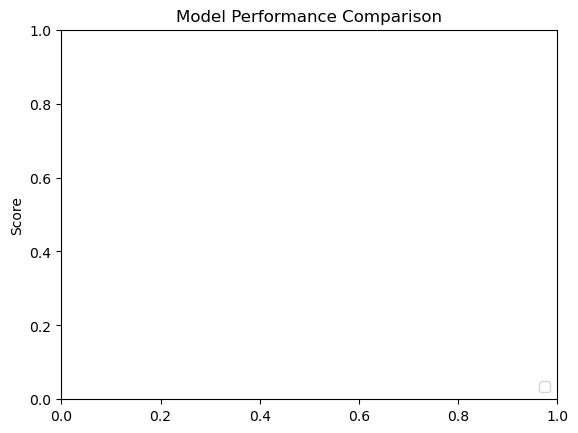

In [63]:
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

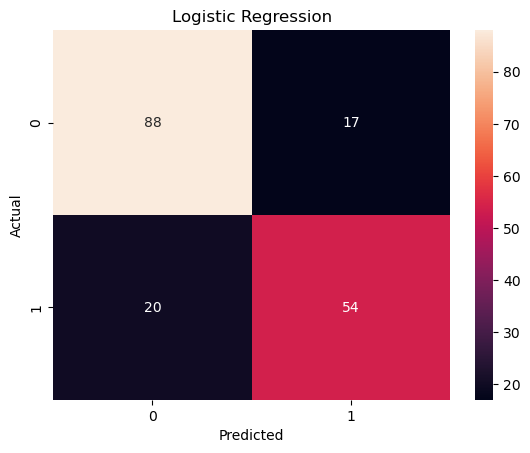

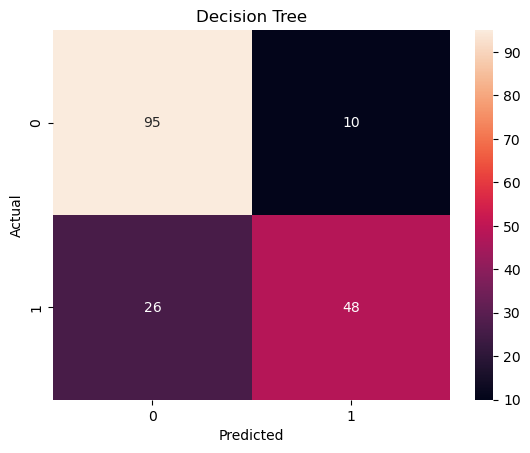

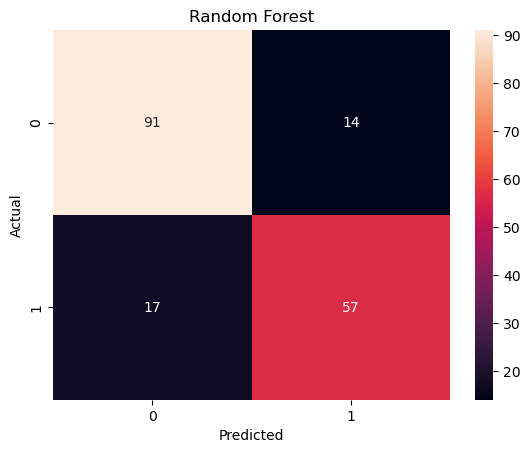

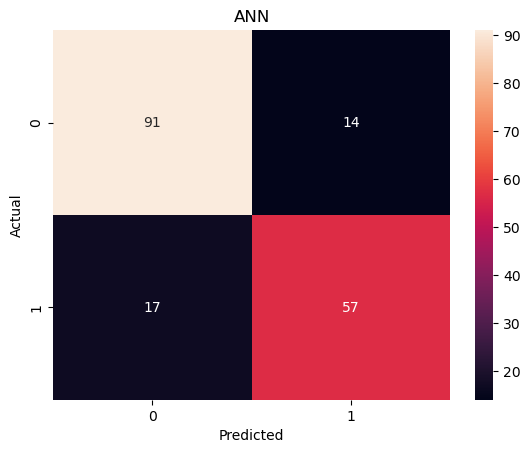

In [64]:
models_all = {
    "Logistic Regression": lr_model.predict(X_test),
    "Decision Tree": dt_model.predict(X_test),
    "Random Forest": rf_model.predict(X_test),
    "ANN": ann_pred
}

for name, pred in models_all.items():
    plt.figure()
    sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt='d')
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [65]:
best_model_name = results_df.loc[results_df["Accuracy"].idxmax(), "Model"]

# Map name to actual trained model objects
trained_models = {
    "Logistic Regression": lr_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "ANN": ann_model
}

best_model = trained_models[best_model_name]

In [66]:
# Logistic Regression
lr_prob = lr_model.predict_proba(X_test)[:, 1]

# Decision Tree
dt_prob = dt_model.predict_proba(X_test)[:, 1]

# Random Forest
rf_prob = rf_model.predict_proba(X_test)[:, 1]

# ANN (already probability output)
ann_prob = ann_model.predict(X_test).ravel()


In [67]:
# Logistic Regression
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
lr_auc = roc_auc_score(y_test, lr_prob)

# Decision Tree
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)
dt_auc = roc_auc_score(y_test, dt_prob)

# Random Forest
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
rf_auc = roc_auc_score(y_test, rf_prob)

# ANN
ann_fpr, ann_tpr, _ = roc_curve(y_test, ann_prob)
ann_auc = roc_auc_score(y_test, ann_prob)

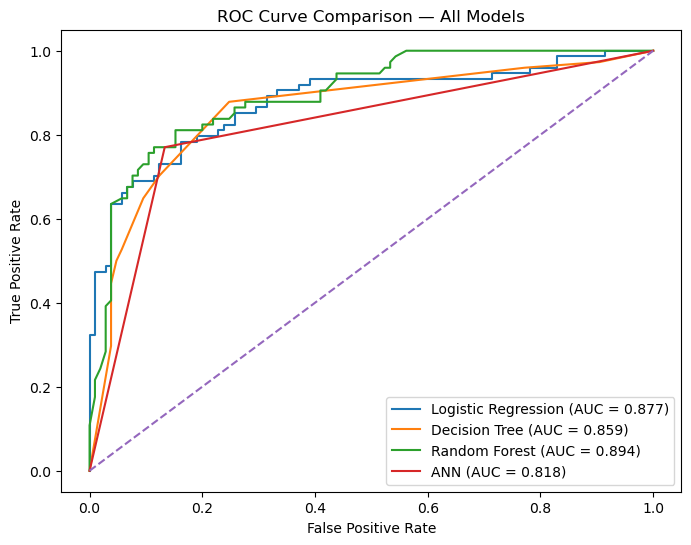

In [68]:
plt.figure(figsize=(8,6))

plt.plot(lr_fpr, lr_tpr, label=f"Logistic Regression (AUC = {lr_auc:.3f})")
plt.plot(dt_fpr, dt_tpr, label=f"Decision Tree (AUC = {dt_auc:.3f})")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_auc:.3f})")
plt.plot(ann_fpr, ann_tpr, label=f"ANN (AUC = {ann_auc:.3f})")

# Random model baseline
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison — All Models")
plt.legend()
plt.show()


In [69]:
import pickle

with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('scale_cols.pkl', 'wb') as f:
    pickle.dump(scale_cols, f)

In [70]:
feature_cols = X.columns.tolist()
with open('feature_cols.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)